# **Naira to Dollar Exchange Rate Forecast**

This notebook presents a data-driven approach to forecasting the Nigeria–US forex rate using historical time series data. The workflow combines exploratory data analysis (EDA), feature engineering, and machine learning / deep learning models to uncover trends, seasonality, and volatility patterns inherent in the exchange rate movements.

Specifically, the notebook will:

 - Model the exchange rate – using multiple forecasting approaches including:

 - Classical statistical models (ARIMA, SARIMA, VAR)

 - Machine learning models (Random Forest, XGBoost)

 - Deep learning models (LSTM, GRU, or Transformer-based architectures)

 - Evaluate and compare model performance using metrics such as RMSE, MAE, and MAPE.

 - Select the best-performing model for robust short-term and long-term forecasting.

By the end of this notebook, we aim to build a forecasting pipeline capable of producing accurate, explainable, and adaptive predictions of the NGN/USD exchange rate

In [8]:
# import required pacakges
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping    
import warnings
warnings.filterwarnings("ignore")


2025-10-30 14:53:14.912447: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/apple/NGForexCast/.ngforecastenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [9]:
# load features
df_feat = pd.read_csv('../data/03_features/ngn_us_exchange_rates_features.csv')

# Display the feature engineered data
df_feat.head()

,Date,Rate,diff,lag_1,lag_2,lag_6,lag_8,lag_11,lag_13,lag_15,...,ret_3,ret_7,ret_14,ret_21,ret_30,ret_60,ret_90,month,day,year
0,1997-04-11,84.66,-0.29,0.00,0.00,-0.040,0.000,0.08,1.24,-0.22,...,-3.685185,-inf,-0.879167,-1.973154,-6.800000,-0.768000,-1.58,4,11,1997
1,1997-05-02,85.05,0.25,0.00,0.00,0.108,0.560,0.00,0.06,0.30,...,-1.862069,-0.722222,2.125000,-7.250000,inf,-1.297619,inf,5,2,1997
2,1997-05-09,84.48,-0.32,0.25,0.00,0.000,0.900,0.00,0.00,0.08,...,-inf,-3.962963,-6.333333,-inf,0.454545,-1.780488,-1.80,5,9,1997
3,1997-05-16,84.48,0.02,-0.32,0.25,0.000,0.108,-0.04,0.00,0.06,...,inf,inf,inf,-1.909091,-0.600000,-0.900000,-0.96,5,16,1997
4,1997-05-23,84.96,0.41,0.02,-0.32,-0.290,0.000,0.56,0.00,0.00,...,0.640000,inf,inf,-2.863636,-1.745455,inf,inf,5,23,1997


In [10]:
# Convert transaction_time column to date format
df_feat["Date"] = pd.to_datetime(df_feat["Date"], errors="coerce")

In [11]:
# Train-test split (time split)
test_size = int(len(df_feat)*0.012)
train = df_feat.iloc[:-test_size].copy()
test = df_feat.iloc[-test_size:].copy()

print("Train range:", train['Date'].min().date(), "to", train['Date'].max().date())
print("Test range:", test['Date'].min().date(), "to", test['Date'].max().date())

Train range: 1997-04-11 to 2025-07-18
Test range: 2025-07-25 to 2025-10-17


In [16]:
import random
random.seed(12345)
import statsmodels.api as sm
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

In [ ]:
# Define parameter ranges for grid search
P_MAX = 35  # Reduced from 5
D_MAX = 35 # Reduced from 5
Q_MAX = 35  # Reduced from 5
p_MAX = 35  # Reduced from 5
d_MAX = 1  
q_MAX = 35  # Reduced from 5
s = 52     # Weekly seasonality

scores = []
total_iterations = P_MAX * D_MAX * Q_MAX * p_MAX * d_MAX * q_MAX
current_iteration = 0

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc="SARIMA Grid Search")

for p in range(p_MAX):
    for d in range(d_MAX):
        for q in range(q_MAX):
            for P in range(P_MAX):
                for D_s in range(D_MAX):
                    for Q in range(Q_MAX):
                        try:
                            # Create and fit model
                            mod = sm.tsa.statespace.SARIMAX(
                                train["diff"],
                                order=(p, d, q),
                                seasonal_order=(P, D_s, Q, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            
                            with warnings.catch_warnings():
                                warnings.filterwarnings('ignore')
                                res = mod.fit(disp=False, maxiter=50)
                            
                            # Compute metrics
                            forecast = res.forecast(steps=len(test))
                            r2 = r2_score(test["diff"], forecast)
                            aic = res.aic
                            bic = res.bic
                            
                            score = [p, d, q, P, D_s, Q, r2, aic, bic]
                            scores.append(score)
                            
                            # Clean up
                            del mod, res
                            
                        except Exception as e:
                            print(e)
                        
                        current_iteration += 1
                        pbar.update(1)

pbar.close()

# Convert scores to DataFrame if any models were successful
if scores:
    res = pd.DataFrame(scores)
    res.columns = ['p', 'd', 'q', 'P', 'D', 'Q', 'R2', 'AIC', 'BIC']
    print("\nTop 10 models by R2:")
    print(res.sort_values('R2', ascending=False).head(10))
    print("\nTop 10 models by AIC:")
    print(res.sort_values('AIC').head(10))
else:
    print("No successful models found. Try adjusting parameters or data preprocessing.")

SARIMA Grid Search:   0%|          | 7/52521875 [3:58:43<67251356:25:54, 4609.60s/it]

In [ ]:
print("done")

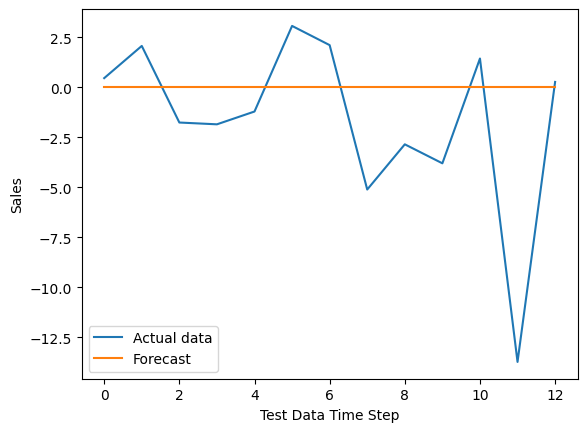

-0.14461562168611275

In [13]:
mod = sm.tsa.statespace.SARIMAX(train["diff"], order=(0,0,0), seasonal_order=(0,0,0,52))
res = mod.fit(disp=False)
fcst = res.forecast(len(test))
plt.plot(list(test["diff"]))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('Sales')
plt.xlabel('Test Data Time Step')
plt.show()
r2_score(test["diff"], fcst)

In [6]:
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA

0.0034713466262882298
-0.10621280006737144


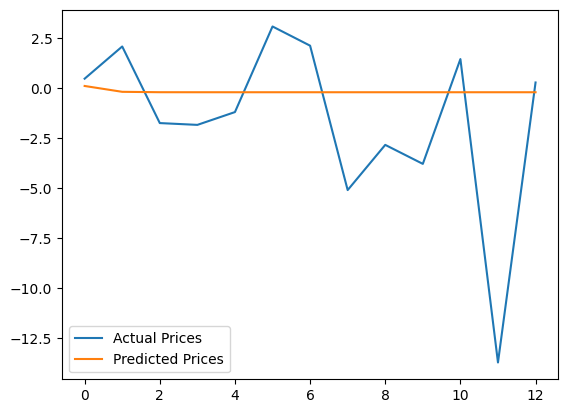

In [7]:
# Forecast the first MA(1) model
mod = ARIMA(train["diff"], order=(1,1,1))
res = mod.fit()
pred = res.predict()
fcst = res.forecast(steps = len(test))
print(r2_score(train["diff"], pred))
print(r2_score(test["diff"], fcst))
plt.plot(list(test["diff"]))
plt.plot(list(fcst))
plt.legend(['Actual Prices', 'Predicted Prices'])
plt.show()

In [8]:
# from statsmodels.regression.linear_model import yule_walker
# order = 3
# coefficients, sigma = yule_walker(df_feat['diff'], order = order)
# # Make a list of differenced values
# val_list = list(df_feat["diff"])[-order:]
# forecasted_values = []
# # Reverse the list so that the order corresponds with the order of the coefficients
# val_list.reverse()
# # Define the number of years to predict
# n_steps = 100
# # For each year to predict
# for i in range(n_steps):
#     # Compute the new value as the sum of lagged values multiplied by their corresponding coefficient
#     new_val = 0
#     for j in range(len(coefficients)):
#         new_val += coefficients[j] * val_list[j]
#     # Insert the new value at the beginning of the list
#     forecasted_values.append(new_val)


# # generate new dates for the next 10 days
# new_dates = pd.date_range(start=df_feat["Date"].values[-1] + np.timedelta64(1, 'D'), periods=n_steps, freq='D')

# # Add the original first value back into the list and do a cumulative sum
# # to undo the differencing

# val_list = [df_feat["Rate"].values[-1]] + val_list
# new_val_list = pd.Series(val_list).cumsum()
# # Plot the newly obtained list
# plt.plot(new_dates, forecasted_values)
# plt.ylabel('Forex Forecast')
# plt.show()

In [9]:
# # Plot the newly obtained list
# validation = pd.DataFrame({
#     'original': earthquakes_per_year.reset_index(drop=True),
#     'pred': new_val_list })
# print('Test R2:', r2_score(validation.iloc[-10:, 0], validation.iloc[-10:, 1]))
# # Plot the newly obtained list
# plt.plot(range(1966, 2015), validation)
# plt.legend(validation.columns)
# plt.ylabel('Number of earthquakes')
# plt.show()

Train range: 1995-08-10 to 2025-04-26
Test range: 2025-04-27 to 2025-10-23


In [5]:
# Features and target
feature_cols = [c for c in df_feat.columns if c not in ['Date','Rate']]
X_train = train[feature_cols]
y_train = train['Rate']
X_test = test[feature_cols]
y_test = test['Rate']

In [6]:
# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Metrics storage
results = []

In [8]:
# Baseline 1: Naive (y_hat = last observed rate)
y_pred_naive = np.repeat(train['Rate'].iloc[-1], len(y_test))
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = mean_squared_error(y_test, y_pred_naive)
mape_naive = np.mean(np.abs((y_test - y_pred_naive) / y_test)) * 100
results.append(("NaiveLastValue", mae_naive, rmse_naive, mape_naive))

In [9]:
# Baseline 2: Persistence (y_hat = yesterday's rate) -> use lag_1 from test
y_pred_pers = X_test['lag_1'].values
mae_pers = mean_absolute_error(y_test, y_pred_pers)
rmse_pers = mean_squared_error(y_test, y_pred_pers)
mape_pers = np.mean(np.abs((y_test - y_pred_pers) / y_test)) * 100
results.append(("PersistenceLag1", mae_pers, rmse_pers, mape_pers))

In [10]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(("RandomForest", mean_absolute_error(y_test, y_pred_rf),
                mean_squared_error(y_test, y_pred_rf),
                np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100))

In [13]:
# Gradient Boosting (sklearn)
gbr = GradientBoostingRegressor(n_estimators=200, random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
results.append(("GradientBoosting", mean_absolute_error(y_test, y_pred_gbr),
                mean_squared_error(y_test, y_pred_gbr),
                np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100))

In [14]:
# SARIMAX (try if statsmodels available)
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    # use simple orders (1,1,1) (1,1,1,12) seasonal - this is a starting point; auto_arima would be preferable if available
    sar_order = (1,1,1)
    sea_order = (1,1,1,12)
    sar_model = SARIMAX(train['rate'], order=sar_order, seasonal_order=sea_order, enforce_stationarity=False, enforce_invertibility=False)
    sar_res = sar_model.fit(disp=False)
    sar_pred = sar_res.get_forecast(steps=len(test)).predicted_mean
    results.append(("SARIMAX(1,1,1)(1,1,1,12)", mean_absolute_error(y_test, sar_pred),
                    mean_squared_error(y_test, sar_pred, squared=False),
                    np.mean(np.abs((y_test - sar_pred) / y_test)) * 100))
    # align for plotting later
    sar_pred = np.array(sar_pred)
except Exception as e:
    print("SARIMAX skipped:", e)
    sar_pred = None

SARIMAX skipped: 'rate'


In [17]:
# Optional LSTM (if tensorflow/keras available) - simple 1-layer model using lag features
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, LSTM, Dropout
    # Prepare data with lag window (use lag_30, lag_14... already in features). We'll reshape X to (samples, timesteps=1, features)
    X_train_l = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_l = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
    model = Sequential()
    model.add(LSTM(64, input_shape=(X_train_l.shape[1], X_train_l.shape[2])))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train_l, y_train, epochs=20, batch_size=32, verbose=0)
    y_pred_lstm = model.predict(X_test_l).flatten()
    results.append(("LSTM", mean_absolute_error(y_test, y_pred_lstm),
                    mean_squared_error(y_test, y_pred_lstm),
                    np.mean(np.abs((y_test - y_pred_lstm) / y_test)) * 100))
except Exception as e:
    print("LSTM skipped:", e)

2025-10-27 21:30:13.297021: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-10-27 21:30:13.299513: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-10-27 21:30:13.301748: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

6/6 [==============================] - 1s 2ms/step


In [21]:
# Summarize results
res_df = pd.DataFrame(results, columns=["model","MAE","RMSE","MAPE"])
print("Model results", res_df.sort_values("MAE"))

Model results               model          MAE          RMSE       MAPE
1   PersistenceLag1     2.042111  1.453802e+01   0.133384
2      RandomForest     4.538692  3.792412e+01   0.297534
3  GradientBoosting     5.329956  4.992421e+01   0.347961
0    NaiveLastValue    72.114611  6.879644e+03   4.770903
4              LSTM  1424.212200  2.030064e+06  92.742753


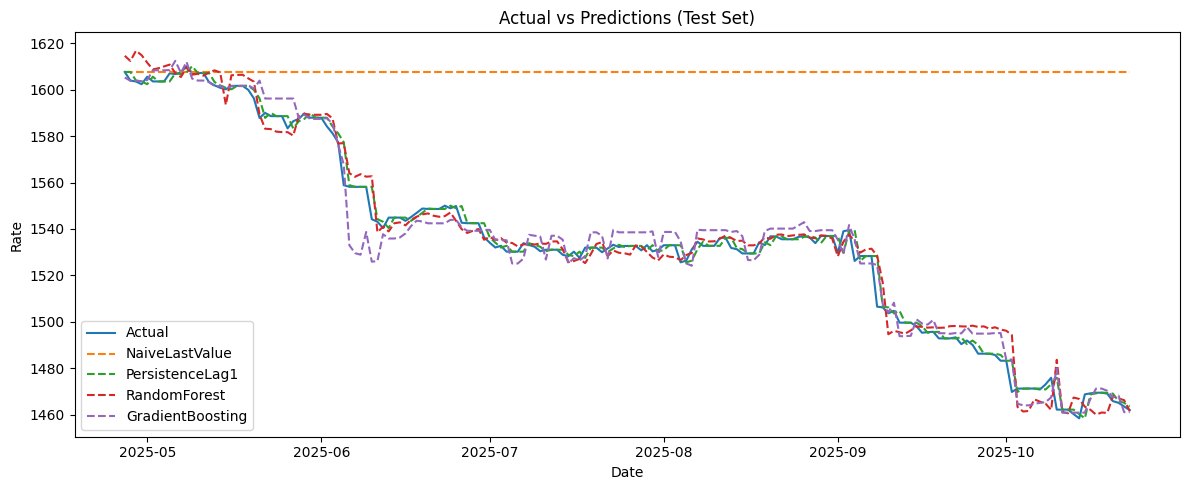

In [24]:
# Plot actual vs predictions for top models (if available)
plt.figure(figsize=(12,5))
plt.plot(test['Date'], y_test.values, label='Actual')
plt.plot(test['Date'], y_pred_naive, label='NaiveLastValue', linestyle='--')
plt.plot(test['Date'], y_pred_pers, label='PersistenceLag1', linestyle='--')
plt.plot(test['Date'], y_pred_rf, label='RandomForest', linestyle='--')
plt.plot(test['Date'], y_pred_gbr, label='GradientBoosting', linestyle='--')
if sar_pred is not None:
    plt.plot(test['Date'], sar_pred, label='SARIMAX', linestyle='--')
plt.legend()
plt.title("Actual vs Predictions (Test Set)")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()